In [23]:
import numpy as np, h5py
from pathlib import Path

R   = Path("/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq")
OUT = Path("/grid/koo/home/pmantill/projects/SEAM_validate/cluster_assess/results")
REF_SEQ = "peak84030"

# qualitatively selected reference config per seq (starred in the plots below)
SELECTED = {"peak26256": "100k_k200", "peak84030": "300k_k300", "peak27535_Reversed": "100k_k300"}
SEL_LABEL = SELECTED.get(REF_SEQ)

def lib_suffix(fg):
    if fg.startswith("foregrounds_mut5_200k"): return "_mut5_200k"
    if fg.startswith("foregrounds_mut5_300k"): return "_mut5_300k"
    if fg.startswith("foregrounds_mut5"):      return "_mut5"
    if fg.startswith("foregrounds_200k"):      return "_200k"
    if fg.startswith("foregrounds_300k"):      return "_300k"
    return ""
LIB_LABEL = {"": "100k", "_200k": "200k", "_300k": "300k",
             "_mut5": "mut5", "_mut5_200k": "mut5-200k", "_mut5_300k": "mut5-300k"}

runs = []
for fg in sorted(p.name for p in R.glob("foregrounds*") if p.is_dir()):
    if "deepshap" in fg:
        continue
    if fg.startswith("foregrounds_mut5"):        # 10% mut only -> drop all 5% (mut5) libraries
        continue
    fg_dir = R / fg / REF_SEQ
    suf    = lib_suffix(fg)
    ism_h5 = R / f"ism{suf}" / f"{REF_SEQ}.h5"
    if not (fg_dir / "cluster_labels.npy").exists() or not ism_h5.exists():
        continue
    labels = np.load(fg_dir / "cluster_labels.npy")
    lib    = LIB_LABEL[suf]
    runs.append(dict(fg_dir=fg_dir, ism_h5=ism_h5, random_labels=None,
                     label=f"{lib}_k{len(np.unique(labels))}"))
    # matched random control: same library shuffled into the same # of clusters (seed = K)
    K = len(np.unique(labels))
    rl = np.random.default_rng(K).integers(0, K, size=len(labels)).astype(np.int32)
    runs.append(dict(fg_dir=None, ism_h5=ism_h5, random_labels=rl,
                     label=f"rand-{lib}_k{K}"))
print(f"{len(runs)} runs for {REF_SEQ}  (selected config: {SEL_LABEL})")

32 runs for peak84030  (selected config: 300k_k300)


In [24]:
# R = ||fbar||^2 / (mean_i ||f_i - fbar||^2)  for each run's WT cluster (WT = library row 0)
# each ism h5 is read whole ONCE and cached (6 files serve all 50 runs), then sliced in memory
_ism = {}
def load_ism(path):
    key = str(path)
    if key not in _ism:
        with h5py.File(path) as f:
            _ism[key] = f["ism_centered"][:].reshape(f["ism_centered"].shape[0], -1)  # (N, 800)
    return _ism[key]

scatter = {}
for r in runs:
    labels  = r["random_labels"] if r["random_labels"] is not None else np.load(r["fg_dir"] / "cluster_labels.npy")
    members = np.where(labels == int(labels[0]))[0]
    X    = load_ism(r["ism_h5"])[members].astype(np.float64)    # (M, 800)
    fbar = X.mean(0)
    noise = float(np.mean(np.sum((X - fbar) ** 2, axis=1)))
    scatter[r["label"]] = float(np.sum(fbar ** 2) / noise)
    print(f"{r['label']:22s}  M={len(members):6d}  R={scatter[r['label']]:.4f}")

100k_k50                M=  3580  R=11.0542
rand-100k_k50           M=  1951  R=0.8023
200k_k100               M=  2403  R=13.8496
rand-200k_k100          M=  2048  R=0.7897
200k_k150               M=  1884  R=12.4494
rand-200k_k150          M=  1352  R=0.7966
200k_k200               M=  1487  R=13.4620
rand-200k_k200          M=  1031  R=0.8044
200k_k300               M=  1035  R=13.5908
rand-200k_k300          M=   685  R=0.8407
300k_k50                M= 10245  R=11.6694
rand-300k_k50           M=  5997  R=0.7765
300k_k100               M=  5323  R=12.7375
rand-300k_k100          M=  3081  R=0.7848
300k_k200               M=  2578  R=12.7100
rand-300k_k200          M=  1509  R=0.8044
300k_k300               M=  1650  R=16.4191
rand-300k_k300          M=   998  R=0.7915
300k_k400               M=  1392  R=16.0495
rand-300k_k400          M=   717  R=0.7947
100k_k100               M=  1528  R=8.9134
rand-100k_k100          M=  1016  R=0.7842
100k_k200               M=   877  R=14.0807


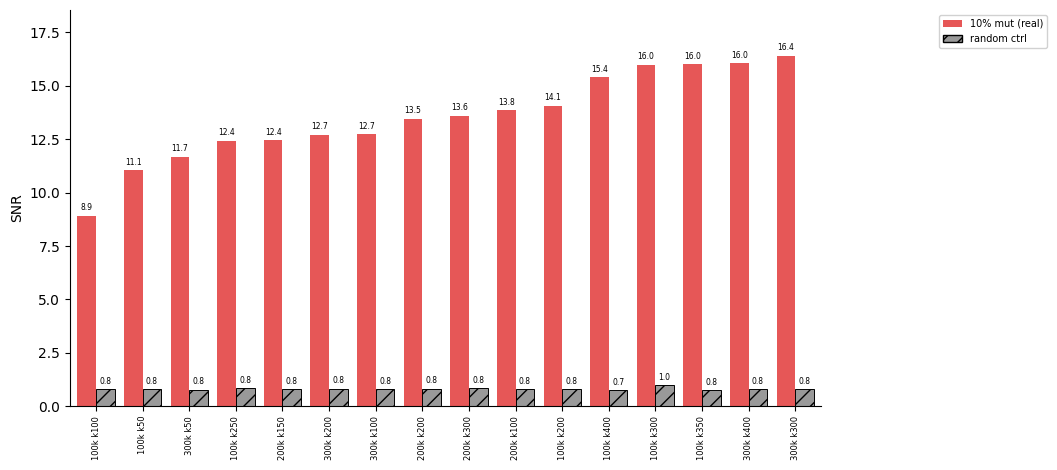

saved: /grid/koo/home/pmantill/projects/SEAM_validate/cluster_assess/results/peak84030_wt_cluster_snr.png


In [25]:
import matplotlib.pyplot as plt, colorsys
from matplotlib.patches import Patch

# --- ordering: one x-tick per config (real + its random control side by side),
#     ticks sorted by the REAL bar's value so improvement runs left -> right (best config at the right) ---
def kof(l):   return int(l.split("_k")[-1])
def basel(l):
    lib = l.split("_k")[0]
    return lib[5:] if lib.startswith("rand-") else lib          # strip "rand-"

def grouped_bar(valdict, ylabel, title, savename, fmt="{:.1f}", errdict=None, higher_better=True):
    reals = [l for l in valdict if not l.startswith("rand-")]
    order = sorted(reals, key=lambda l: valdict[l], reverse=not higher_better)   # best real rightmost
    xs    = list(range(len(order)))
    W     = 0.4                                                 # half-width offset for the paired bars
    real_color = colorsys.hsv_to_rgb(0.0, 0.62, 0.90)          # single mut rate (10%) -> one color
    def err(l): return errdict[l] if (errdict and l in errdict) else 0
    ymax  = max(valdict[l] + err(l) for l in valdict)
    fig, ax = plt.subplots(figsize=(max(8, 0.55 * len(order) + 2), 4.8))
    for xi, l in zip(xs, order):
        rl = "rand-" + l
        ax.bar(xi - W / 2, valdict[l], width=W, color=real_color, edgecolor="none",
               yerr=(err(l) if errdict else None), capsize=2, error_kw=dict(elinewidth=0.7, ecolor="0.25"))
        ax.text(xi - W / 2, valdict[l] + err(l) + ymax * 0.01, fmt.format(valdict[l]), ha="center", va="bottom", fontsize=5.5)
        if rl in valdict:                                      # matched random control, just to the right
            ax.bar(xi + W / 2, valdict[rl], width=W, color="0.6", hatch="//", edgecolor="black", linewidth=0.7,
                   yerr=(err(rl) if errdict else None), capsize=2, error_kw=dict(elinewidth=0.7, ecolor="0.25"))
            ax.text(xi + W / 2, valdict[rl] + err(rl) + ymax * 0.01, fmt.format(valdict[rl]),
                    ha="center", va="bottom", fontsize=5.5)
    ax.set_xticks(xs)
    ax.set_xticklabels([f"{basel(l)} k{kof(l)}" for l in order], rotation=90, fontsize=6)
    ax.set_ylabel(ylabel); ax.set_ylim(0, ymax * 1.13); ax.margins(x=0.01)
    ax.spines[["top", "right"]].set_visible(False)
    handles = [Patch(facecolor=real_color, label="10% mut (real)"),
               Patch(facecolor="0.6", edgecolor="black", hatch="//", label="random ctrl")]
    ax.legend(handles=handles, fontsize=7, loc="upper left", bbox_to_anchor=(1.15, 1), framealpha=0.9)
    fig.tight_layout()
    fig.savefig(OUT / savename, dpi=300, bbox_inches="tight")
    plt.show()
    print("saved:", OUT / savename)

grouped_bar(scatter, r"SNR",
            f"{REF_SEQ} — WT-cluster signal-to-noise", f"{REF_SEQ}_wt_cluster_snr.png")

100k_k50                n_clust=   49  R=2.9711 +/- 2.7069
rand-100k_k50           n_clust=   49  R=0.7910 +/- 0.0198
200k_k100               n_clust=   99  R=3.3844 +/- 3.0655
rand-200k_k100          n_clust=   99  R=0.7886 +/- 0.0212
200k_k150               n_clust=  149  R=3.6306 +/- 3.2936
rand-200k_k150          n_clust=  149  R=0.7890 +/- 0.0273
200k_k200               n_clust=  199  R=3.7384 +/- 3.3620
rand-200k_k200          n_clust=  199  R=0.7894 +/- 0.0302
200k_k300               n_clust=  299  R=3.9905 +/- 3.5065
rand-200k_k300          n_clust=  299  R=0.7901 +/- 0.0379
300k_k50                n_clust=   49  R=2.9990 +/- 2.7756
rand-300k_k50           n_clust=   49  R=0.7900 +/- 0.0135
300k_k100               n_clust=   99  R=3.2037 +/- 2.9094
rand-300k_k100          n_clust=   99  R=0.7901 +/- 0.0184
300k_k200               n_clust=  199  R=3.5889 +/- 3.2279
rand-300k_k200          n_clust=  199  R=0.7905 +/- 0.0228
300k_k300               n_clust=  299  R=3.6968 +/- 3.27

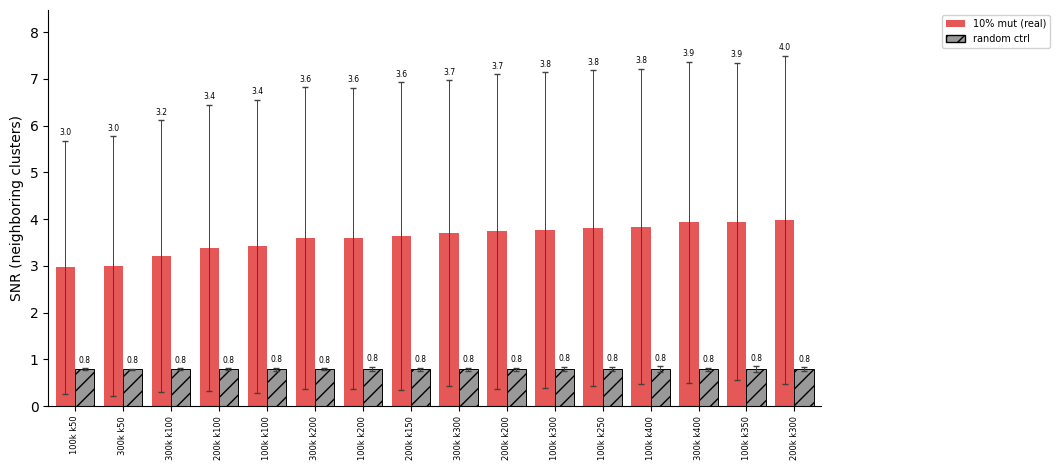

saved: /grid/koo/home/pmantill/projects/SEAM_validate/cluster_assess/results/peak84030_neighbor_cluster_snr.png


In [26]:
# Neighboring-cluster version of the Euclidean SNR: same R = ||fbar_c||^2 / mean_i ||f_i - fbar_c||^2,
# computed per cluster c (excluding the WT cluster), then averaged +/- std across clusters.
scatter_nb, scatter_nb_err = {}, {}
for r in runs:
    labels  = r["random_labels"] if r["random_labels"] is not None else np.load(r["fg_dir"] / "cluster_labels.npy")
    wt_c    = int(labels[0])
    X_all   = load_ism(r["ism_h5"]).astype(np.float64)
    per_cluster = []
    for c in np.unique(labels):
        if c == wt_c:                                          # neighboring clusters only
            continue
        X    = X_all[labels == c]
        if len(X) < 2:
            continue
        fbar = X.mean(0)
        noise = float(np.mean(np.sum((X - fbar) ** 2, axis=1)))
        per_cluster.append(float(np.sum(fbar ** 2) / noise))
    per_cluster = np.asarray(per_cluster)
    scatter_nb[r["label"]]     = float(per_cluster.mean())
    scatter_nb_err[r["label"]] = float(per_cluster.std())
    print(f"{r['label']:22s}  n_clust={len(per_cluster):5d}  R={scatter_nb[r['label']]:.4f} +/- {scatter_nb_err[r['label']]:.4f}")

grouped_bar(scatter_nb, r"SNR (neighboring clusters)",
            f"{REF_SEQ} — neighboring-cluster signal-to-noise (mean +/- std)",
            f"{REF_SEQ}_neighbor_cluster_snr.png", errdict=scatter_nb_err)

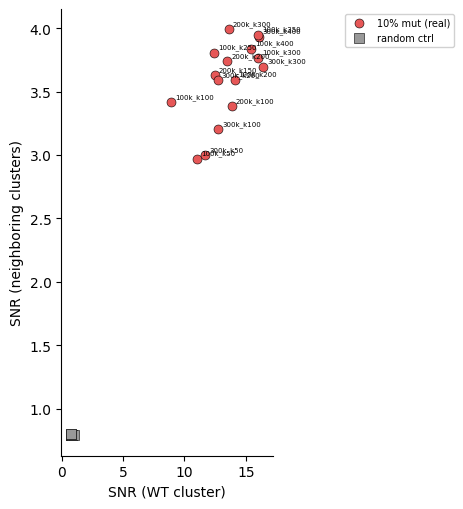

saved: /grid/koo/home/pmantill/projects/SEAM_validate/cluster_assess/results/peak84030_snr_wt_vs_neighbor_scatter.png


In [27]:
# WT vs neighboring scatter: one point per run, WT-cluster metric on x, mean neighboring-cluster metric on y.
def metric_scatter(wt, nb, xlabel, ylabel, title, savename):
    reals = [l for l in wt if not l.startswith("rand-") and l in nb]
    rands = [l for l in wt if l.startswith("rand-") and l in nb]
    fig, ax = plt.subplots(figsize=(5.4, 5.2))
    ax.scatter([wt[l] for l in reals], [nb[l] for l in reals], s=42,
               color=colorsys.hsv_to_rgb(0.0, 0.62, 0.90), edgecolor="black", linewidth=0.4,
               label="10% mut (real)", zorder=3)
    ax.scatter([wt[l] for l in rands], [nb[l] for l in rands], s=42, marker="s",
               color="0.6", edgecolor="black", linewidth=0.4, label="random ctrl", zorder=3)
    for l in reals:
        ax.annotate(l, (wt[l], nb[l]), fontsize=5, xytext=(3, 3), textcoords="offset points")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.32, 1), framealpha=0.9)
    fig.tight_layout()
    fig.savefig(OUT / savename, dpi=300, bbox_inches="tight")
    plt.show()
    print("saved:", OUT / savename)

metric_scatter(scatter, scatter_nb, "SNR (WT cluster)", "SNR (neighboring clusters)",
               f"{REF_SEQ} — Euclidean SNR: WT vs neighboring", f"{REF_SEQ}_snr_wt_vs_neighbor_scatter.png")

100k_k50                M=  3580  R_cos=23.4261
rand-100k_k50           M=  1951  R_cos=1.7041
200k_k100               M=  2403  R_cos=29.5040
rand-200k_k100          M=  2048  R_cos=1.6565
200k_k150               M=  1884  R_cos=26.2988
rand-200k_k150          M=  1352  R_cos=1.6835
200k_k200               M=  1487  R_cos=28.4120
rand-200k_k200          M=  1031  R_cos=1.7069
200k_k300               M=  1035  R_cos=28.5788
rand-200k_k300          M=   685  R_cos=1.7262
300k_k50                M= 10245  R_cos=24.8055
rand-300k_k50           M=  5997  R_cos=1.6424
300k_k100               M=  5323  R_cos=27.2695
rand-300k_k100          M=  3081  R_cos=1.6675
300k_k200               M=  2578  R_cos=26.6828
rand-300k_k200          M=  1509  R_cos=1.6890
300k_k300               M=  1650  R_cos=34.4720
rand-300k_k300          M=   998  R_cos=1.7011
300k_k400               M=  1392  R_cos=33.5934
rand-300k_k400          M=   717  R_cos=1.6826
100k_k100               M=  1528  R_cos=18.9333
ra

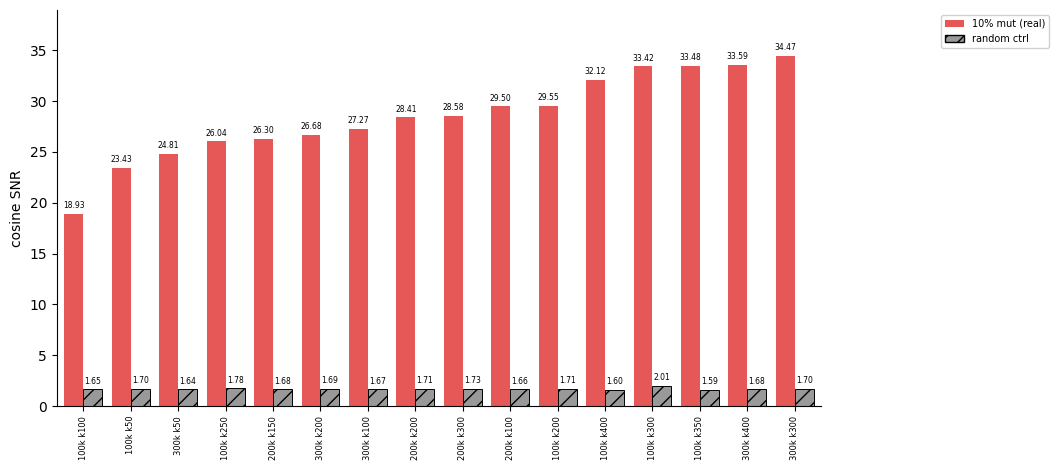

saved: /grid/koo/home/pmantill/projects/SEAM_validate/cluster_assess/results/peak84030_wt_cluster_cosine_snr.png


In [28]:
# Cosine SNR (same ratio shape as the Euclidean one, cosine distance about the cluster mean):
#   R_cos = mean_i cos(f_i, fbar) / mean_i (1 - cos(f_i, fbar))   -- signal alignment / residual misalignment
# fbar = cluster-mean (consensus) map. Coherent WT cluster -> large; random subset -> ~ small.
cos_snr = {}
for r in runs:
    labels  = r["random_labels"] if r["random_labels"] is not None else np.load(r["fg_dir"] / "cluster_labels.npy")
    members = np.where(labels == int(labels[0]))[0]
    X    = load_ism(r["ism_h5"])[members].astype(np.float64)          # (M, 800)
    fbar = X.mean(0)
    cos  = (X @ fbar) / (np.linalg.norm(X, axis=1) * np.linalg.norm(fbar) + 1e-12)
    cos_snr[r["label"]] = float(cos.mean() / (np.mean(1.0 - cos) + 1e-12))
    print(f"{r['label']:22s}  M={len(members):6d}  R_cos={cos_snr[r['label']]:.4f}")

grouped_bar(cos_snr, "cosine SNR",
            f"{REF_SEQ} — WT-cluster cosine SNR", f"{REF_SEQ}_wt_cluster_cosine_snr.png",
            fmt="{:.2f}")

100k_k50                n_clust=   49  R_cos=6.7324 +/- 5.5916
rand-100k_k50           n_clust=   49  R_cos=1.6725 +/- 0.0349
200k_k100               n_clust=   99  R_cos=7.5363 +/- 6.3117
rand-200k_k100          n_clust=   99  R_cos=1.6660 +/- 0.0376
200k_k150               n_clust=  149  R_cos=8.0320 +/- 6.7923
rand-200k_k150          n_clust=  149  R_cos=1.6669 +/- 0.0463
200k_k200               n_clust=  199  R_cos=8.2475 +/- 6.9265
rand-200k_k200          n_clust=  199  R_cos=1.6675 +/- 0.0526
200k_k300               n_clust=  299  R_cos=8.7525 +/- 7.2114
rand-200k_k300          n_clust=  299  R_cos=1.6693 +/- 0.0669
300k_k50                n_clust=   49  R_cos=6.7869 +/- 5.7628
rand-300k_k50           n_clust=   49  R_cos=1.6673 +/- 0.0229
300k_k100               n_clust=   99  R_cos=7.1719 +/- 6.0116
rand-300k_k100          n_clust=   99  R_cos=1.6673 +/- 0.0319
300k_k200               n_clust=  199  R_cos=7.9327 +/- 6.6455
rand-300k_k200          n_clust=  199  R_cos=1.6684 +/-

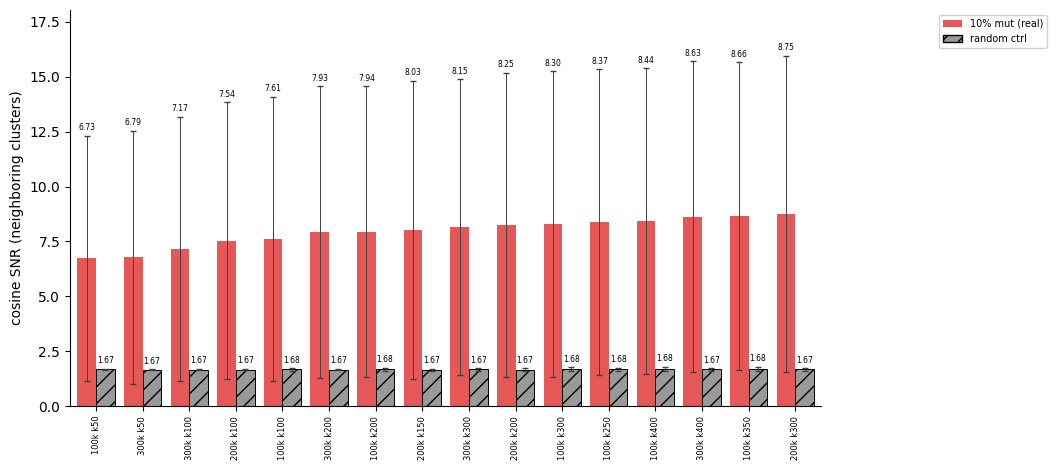

saved: /grid/koo/home/pmantill/projects/SEAM_validate/cluster_assess/results/peak84030_neighbor_cluster_cosine_snr.png


In [29]:
# Neighboring-cluster version of the cosine SNR: same R_cos = mean_i cos(f_i, fbar_c) / mean_i (1 - cos),
# computed per cluster c (excluding the WT cluster), then averaged +/- std across clusters.
cos_snr_nb, cos_snr_nb_err = {}, {}
for r in runs:
    labels  = r["random_labels"] if r["random_labels"] is not None else np.load(r["fg_dir"] / "cluster_labels.npy")
    wt_c    = int(labels[0])
    X_all   = load_ism(r["ism_h5"]).astype(np.float64)
    per_cluster = []
    for c in np.unique(labels):
        if c == wt_c:                                          # neighboring clusters only
            continue
        X    = X_all[labels == c]
        if len(X) < 2:
            continue
        fbar = X.mean(0)
        cos  = (X @ fbar) / (np.linalg.norm(X, axis=1) * np.linalg.norm(fbar) + 1e-12)
        per_cluster.append(float(cos.mean() / (np.mean(1.0 - cos) + 1e-12)))
    per_cluster = np.asarray(per_cluster)
    cos_snr_nb[r["label"]]     = float(per_cluster.mean())
    cos_snr_nb_err[r["label"]] = float(per_cluster.std())
    print(f"{r['label']:22s}  n_clust={len(per_cluster):5d}  R_cos={cos_snr_nb[r['label']]:.4f} +/- {cos_snr_nb_err[r['label']]:.4f}")

grouped_bar(cos_snr_nb, "cosine SNR (neighboring clusters)",
            f"{REF_SEQ} — neighboring-cluster cosine SNR (mean +/- std)",
            f"{REF_SEQ}_neighbor_cluster_cosine_snr.png", fmt="{:.2f}", errdict=cos_snr_nb_err)

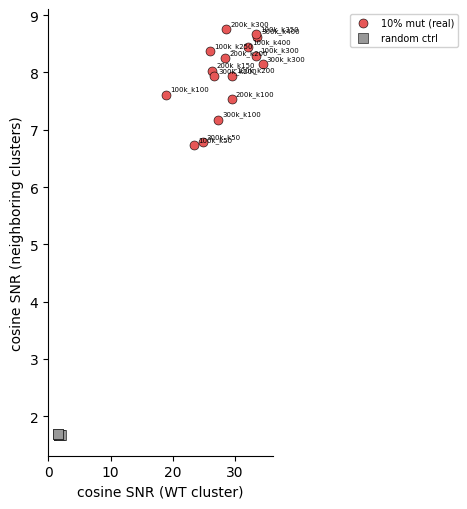

saved: /grid/koo/home/pmantill/projects/SEAM_validate/cluster_assess/results/peak84030_cosine_snr_wt_vs_neighbor_scatter.png


In [30]:
metric_scatter(cos_snr, cos_snr_nb, "cosine SNR (WT cluster)", "cosine SNR (neighboring clusters)",
               f"{REF_SEQ} — cosine SNR: WT vs neighboring", f"{REF_SEQ}_cosine_snr_wt_vs_neighbor_scatter.png")

100k_k50                M=  3580  predvar=0.0338
rand-100k_k50           M=  1951  predvar=2.2895
200k_k100               M=  2403  predvar=0.0193
rand-200k_k100          M=  2048  predvar=2.2710
200k_k150               M=  1884  predvar=0.0331
rand-200k_k150          M=  1352  predvar=2.2640
200k_k200               M=  1487  predvar=0.0193
rand-200k_k200          M=  1031  predvar=2.2540
200k_k300               M=  1035  predvar=0.0242
rand-200k_k300          M=   685  predvar=2.1505
300k_k50                M= 10245  predvar=0.0286
rand-300k_k50           M=  5997  predvar=2.2833
300k_k100               M=  5323  predvar=0.0175
rand-300k_k100          M=  3081  predvar=2.2825
300k_k200               M=  2578  predvar=0.0399
rand-300k_k200          M=  1509  predvar=2.2539
300k_k300               M=  1650  predvar=0.0186
rand-300k_k300          M=   998  predvar=2.2724
300k_k400               M=  1392  predvar=0.0235
rand-300k_k400          M=   717  predvar=2.2666
100k_k100           

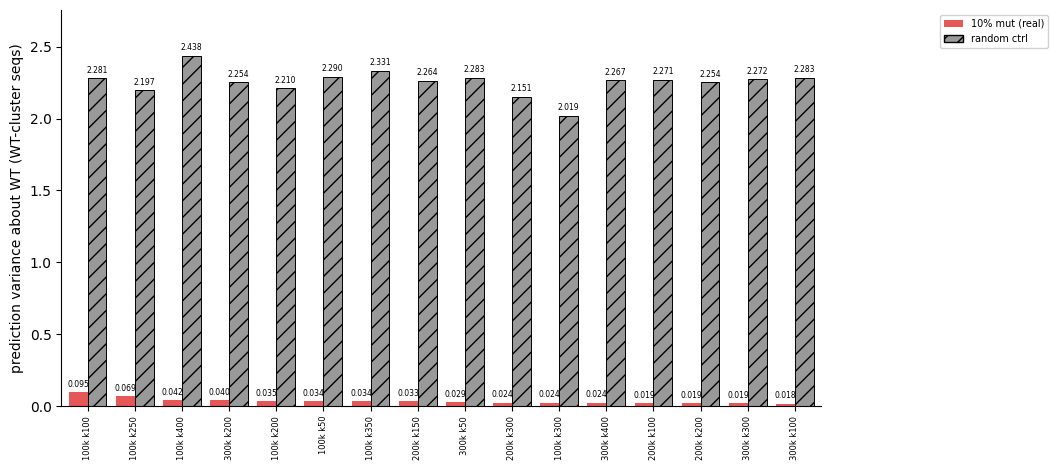

saved: /grid/koo/home/pmantill/projects/SEAM_validate/cluster_assess/results/peak84030_wt_cluster_pred_variance.png


In [31]:
# Variance of model predictions across each run's WT-cluster members, taken about the WT
# prediction (library row 0) rather than the cluster mean. Real WT clusters are functionally
# coherent -> LOW variance about WT; a random subset spans the whole library range -> HIGH.
# predictions cached per ism file (6 files, read once).
_pred = {}
def load_pred(path):
    key = str(path)
    if key not in _pred:
        with h5py.File(path) as f:
            _pred[key] = f["predictions"][:]
    return _pred[key]

predvar = {}
for r in runs:
    labels  = r["random_labels"] if r["random_labels"] is not None else np.load(r["fg_dir"] / "cluster_labels.npy")
    members = np.where(labels == int(labels[0]))[0]
    preds   = load_pred(r["ism_h5"])
    wt      = preds[0]                                              # WT = library row 0
    predvar[r["label"]] = float(np.mean((preds[members] - wt) ** 2))  # variance about WT
    print(f"{r['label']:22s}  M={len(members):6d}  predvar={predvar[r['label']]:.4f}")

grouped_bar(predvar, "prediction variance about WT (WT-cluster seqs)",
            f"{REF_SEQ} — WT-cluster prediction variance about WT", f"{REF_SEQ}_wt_cluster_pred_variance.png",
            fmt="{:.3f}", higher_better=False)

100k_k50                n_clust=   49  predvar=0.0440 +/- 0.0211
rand-100k_k50           n_clust=   49  predvar=0.5778 +/- 0.0113
200k_k100               n_clust=   99  predvar=0.0392 +/- 0.0229
rand-200k_k100          n_clust=   99  predvar=0.5773 +/- 0.0087
200k_k150               n_clust=  149  predvar=0.0371 +/- 0.0210
rand-200k_k150          n_clust=  149  predvar=0.5772 +/- 0.0138
200k_k200               n_clust=  199  predvar=0.0355 +/- 0.0211
rand-200k_k200          n_clust=  199  predvar=0.5773 +/- 0.0166
200k_k300               n_clust=  299  predvar=0.0338 +/- 0.0201
rand-200k_k300          n_clust=  299  predvar=0.5768 +/- 0.0172
300k_k50                n_clust=   49  predvar=0.0430 +/- 0.0202
rand-300k_k50           n_clust=   49  predvar=0.5792 +/- 0.0054
300k_k100               n_clust=   99  predvar=0.0398 +/- 0.0250
rand-300k_k100          n_clust=   99  predvar=0.5790 +/- 0.0098
300k_k200               n_clust=  199  predvar=0.0354 +/- 0.0200
rand-300k_k200          n

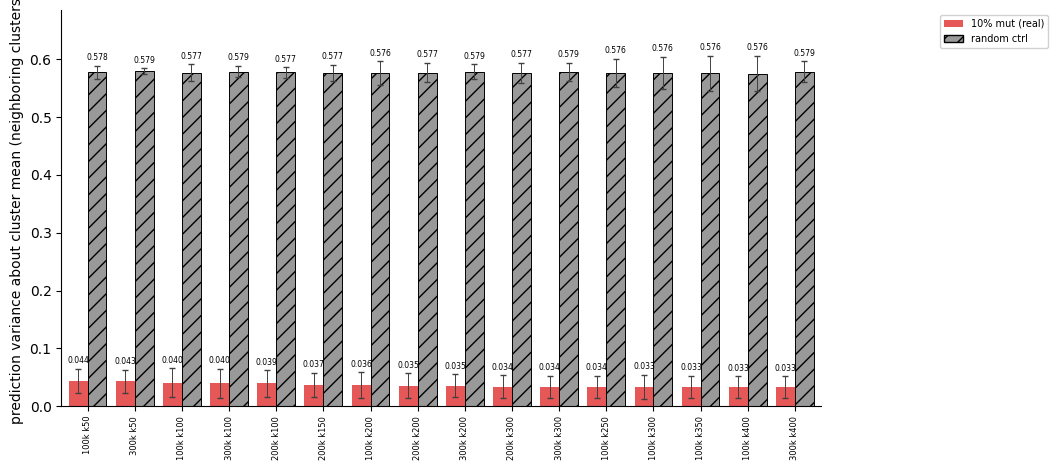

saved: /grid/koo/home/pmantill/projects/SEAM_validate/cluster_assess/results/peak84030_neighbor_cluster_pred_variance.png


In [32]:
# Neighboring-cluster version of the prediction variance. No WT exists per neighboring cluster,
# so variance is taken about each cluster's OWN mean prediction (var_c = mean_i (pred_i - mean_c)^2),
# per cluster c (excluding the WT cluster), then averaged +/- std across clusters.
predvar_nb, predvar_nb_err = {}, {}
for r in runs:
    labels  = r["random_labels"] if r["random_labels"] is not None else np.load(r["fg_dir"] / "cluster_labels.npy")
    wt_c    = int(labels[0])
    preds   = load_pred(r["ism_h5"])
    per_cluster = []
    for c in np.unique(labels):
        if c == wt_c:                                          # neighboring clusters only
            continue
        p = preds[labels == c]
        if len(p) < 2:
            continue
        per_cluster.append(float(np.var(p)))                  # about the cluster mean pred
    per_cluster = np.asarray(per_cluster)
    predvar_nb[r["label"]]     = float(per_cluster.mean())
    predvar_nb_err[r["label"]] = float(per_cluster.std())
    print(f"{r['label']:22s}  n_clust={len(per_cluster):5d}  predvar={predvar_nb[r['label']]:.4f} +/- {predvar_nb_err[r['label']]:.4f}")

grouped_bar(predvar_nb, "prediction variance about cluster mean (neighboring clusters)",
            f"{REF_SEQ} — neighboring-cluster prediction variance (mean +/- std)",
            f"{REF_SEQ}_neighbor_cluster_pred_variance.png", fmt="{:.3f}", errdict=predvar_nb_err,
            higher_better=False)

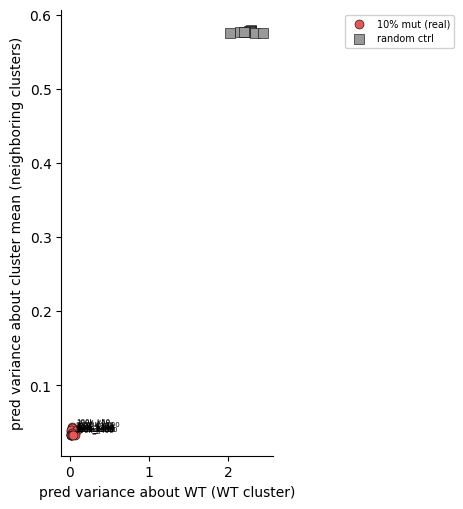

saved: /grid/koo/home/pmantill/projects/SEAM_validate/cluster_assess/results/peak84030_pred_variance_wt_vs_neighbor_scatter.png


In [33]:
metric_scatter(predvar, predvar_nb, "pred variance about WT (WT cluster)",
               "pred variance about cluster mean (neighboring clusters)",
               f"{REF_SEQ} — prediction variance: WT vs neighboring",
               f"{REF_SEQ}_pred_variance_wt_vs_neighbor_scatter.png")

100k_k50                predvar=0.0436  SNR_euc=3.1327  SNR_cos=7.0663
rand-100k_k50           predvar=0.5776  SNR_euc=0.7912  SNR_cos=1.6731
200k_k100               predvar=0.0390  SNR_euc=3.4891  SNR_cos=7.7560
rand-200k_k100          predvar=0.5775  SNR_euc=0.7886  SNR_cos=1.6659
200k_k150               predvar=0.0369  SNR_euc=3.6894  SNR_cos=8.1538
rand-200k_k150          predvar=0.5773  SNR_euc=0.7891  SNR_cos=1.6670
200k_k200               predvar=0.0354  SNR_euc=3.7870  SNR_cos=8.3483
rand-200k_k200          predvar=0.5772  SNR_euc=0.7894  SNR_cos=1.6677
200k_k300               predvar=0.0338  SNR_euc=4.0225  SNR_cos=8.8186
rand-200k_k300          predvar=0.5769  SNR_euc=0.7902  SNR_cos=1.6695
300k_k50                predvar=0.0427  SNR_euc=3.1724  SNR_cos=7.1472
rand-300k_k50           predvar=0.5791  SNR_euc=0.7898  SNR_cos=1.6668
300k_k100               predvar=0.0396  SNR_euc=3.2990  SNR_cos=7.3728
rand-300k_k100          predvar=0.5791  SNR_euc=0.7900  SNR_cos=1.6673
300k_k

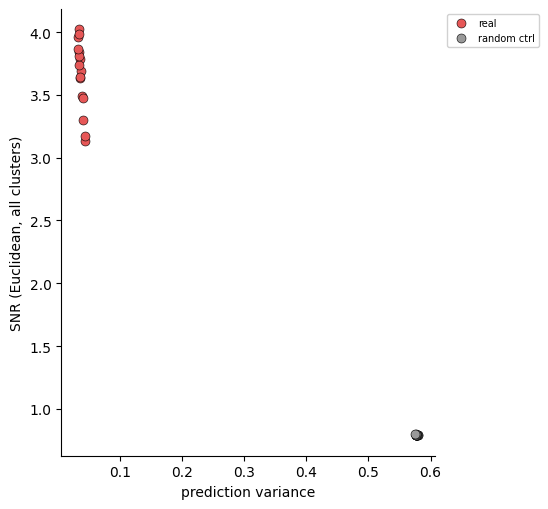

saved: /grid/koo/home/pmantill/projects/SEAM_validate/cluster_assess/results/peak84030_predvar_vs_snr_euclid_scatter.png


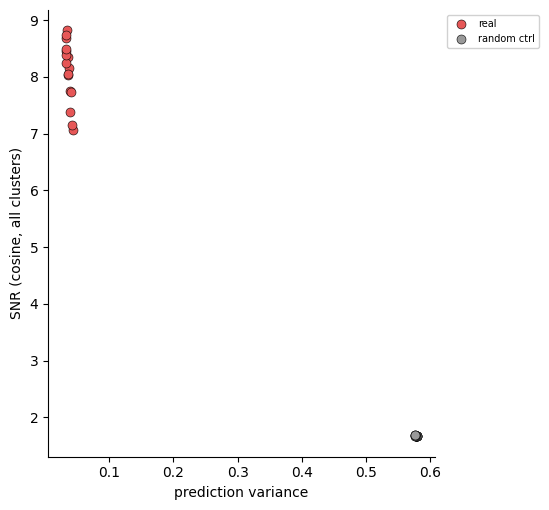

saved: /grid/koo/home/pmantill/projects/SEAM_validate/cluster_assess/results/peak84030_predvar_vs_snr_cosine_scatter.png


In [35]:
# One point per config: aggregate each metric over ALL clusters (WT treated like any other cluster,
# each computed about its OWN mean), then average across clusters. predvar (x) vs SNR (y).
# Two plots: Euclidean SNR and cosine SNR.
snr_euc_all, snr_cos_all, predvar_all = {}, {}, {}
for r in runs:
    labels = r["random_labels"] if r["random_labels"] is not None else np.load(r["fg_dir"] / "cluster_labels.npy")
    X_all  = load_ism(r["ism_h5"]).astype(np.float64)
    preds  = load_pred(r["ism_h5"])
    euc, cos_, pv = [], [], []
    for c in np.unique(labels):
        m = labels == c
        X = X_all[m]
        if len(X) < 2:
            continue
        fbar = X.mean(0)
        euc.append(float(np.sum(fbar ** 2) / np.mean(np.sum((X - fbar) ** 2, axis=1))))
        cc = (X @ fbar) / (np.linalg.norm(X, axis=1) * np.linalg.norm(fbar) + 1e-12)
        cos_.append(float(cc.mean() / (np.mean(1.0 - cc) + 1e-12)))
        pv.append(float(np.var(preds[m])))                    # about the cluster mean pred
    snr_euc_all[r["label"]] = float(np.mean(euc))
    snr_cos_all[r["label"]] = float(np.mean(cos_))
    predvar_all[r["label"]] = float(np.mean(pv))
    print(f"{r['label']:22s}  predvar={predvar_all[r['label']]:.4f}  SNR_euc={snr_euc_all[r['label']]:.4f}  SNR_cos={snr_cos_all[r['label']]:.4f}")

def predvar_snr_scatter(snr, ylabel, savename):
    real_color = colorsys.hsv_to_rgb(0.0, 0.62, 0.90)
    fig, ax = plt.subplots(figsize=(5.6, 5.2))
    for grp, col, lab in [(False, real_color, "real"), (True, "0.6", "random ctrl")]:
        ls = [l for l in snr if l.startswith("rand-") == grp]
        ax.scatter([predvar_all[l] for l in ls], [snr[l] for l in ls], s=42, marker="o",
                   color=col, edgecolor="black", linewidth=0.4, zorder=3, label=lab)
    ax.set_xlabel("prediction variance"); ax.set_ylabel(ylabel)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1), framealpha=0.9)
    fig.tight_layout()
    fig.savefig(OUT / savename, dpi=300, bbox_inches="tight")
    plt.show()
    print("saved:", OUT / savename)

predvar_snr_scatter(snr_euc_all, "SNR (Euclidean, all clusters)", f"{REF_SEQ}_predvar_vs_snr_euclid_scatter.png")
predvar_snr_scatter(snr_cos_all, "SNR (cosine, all clusters)",    f"{REF_SEQ}_predvar_vs_snr_cosine_scatter.png")

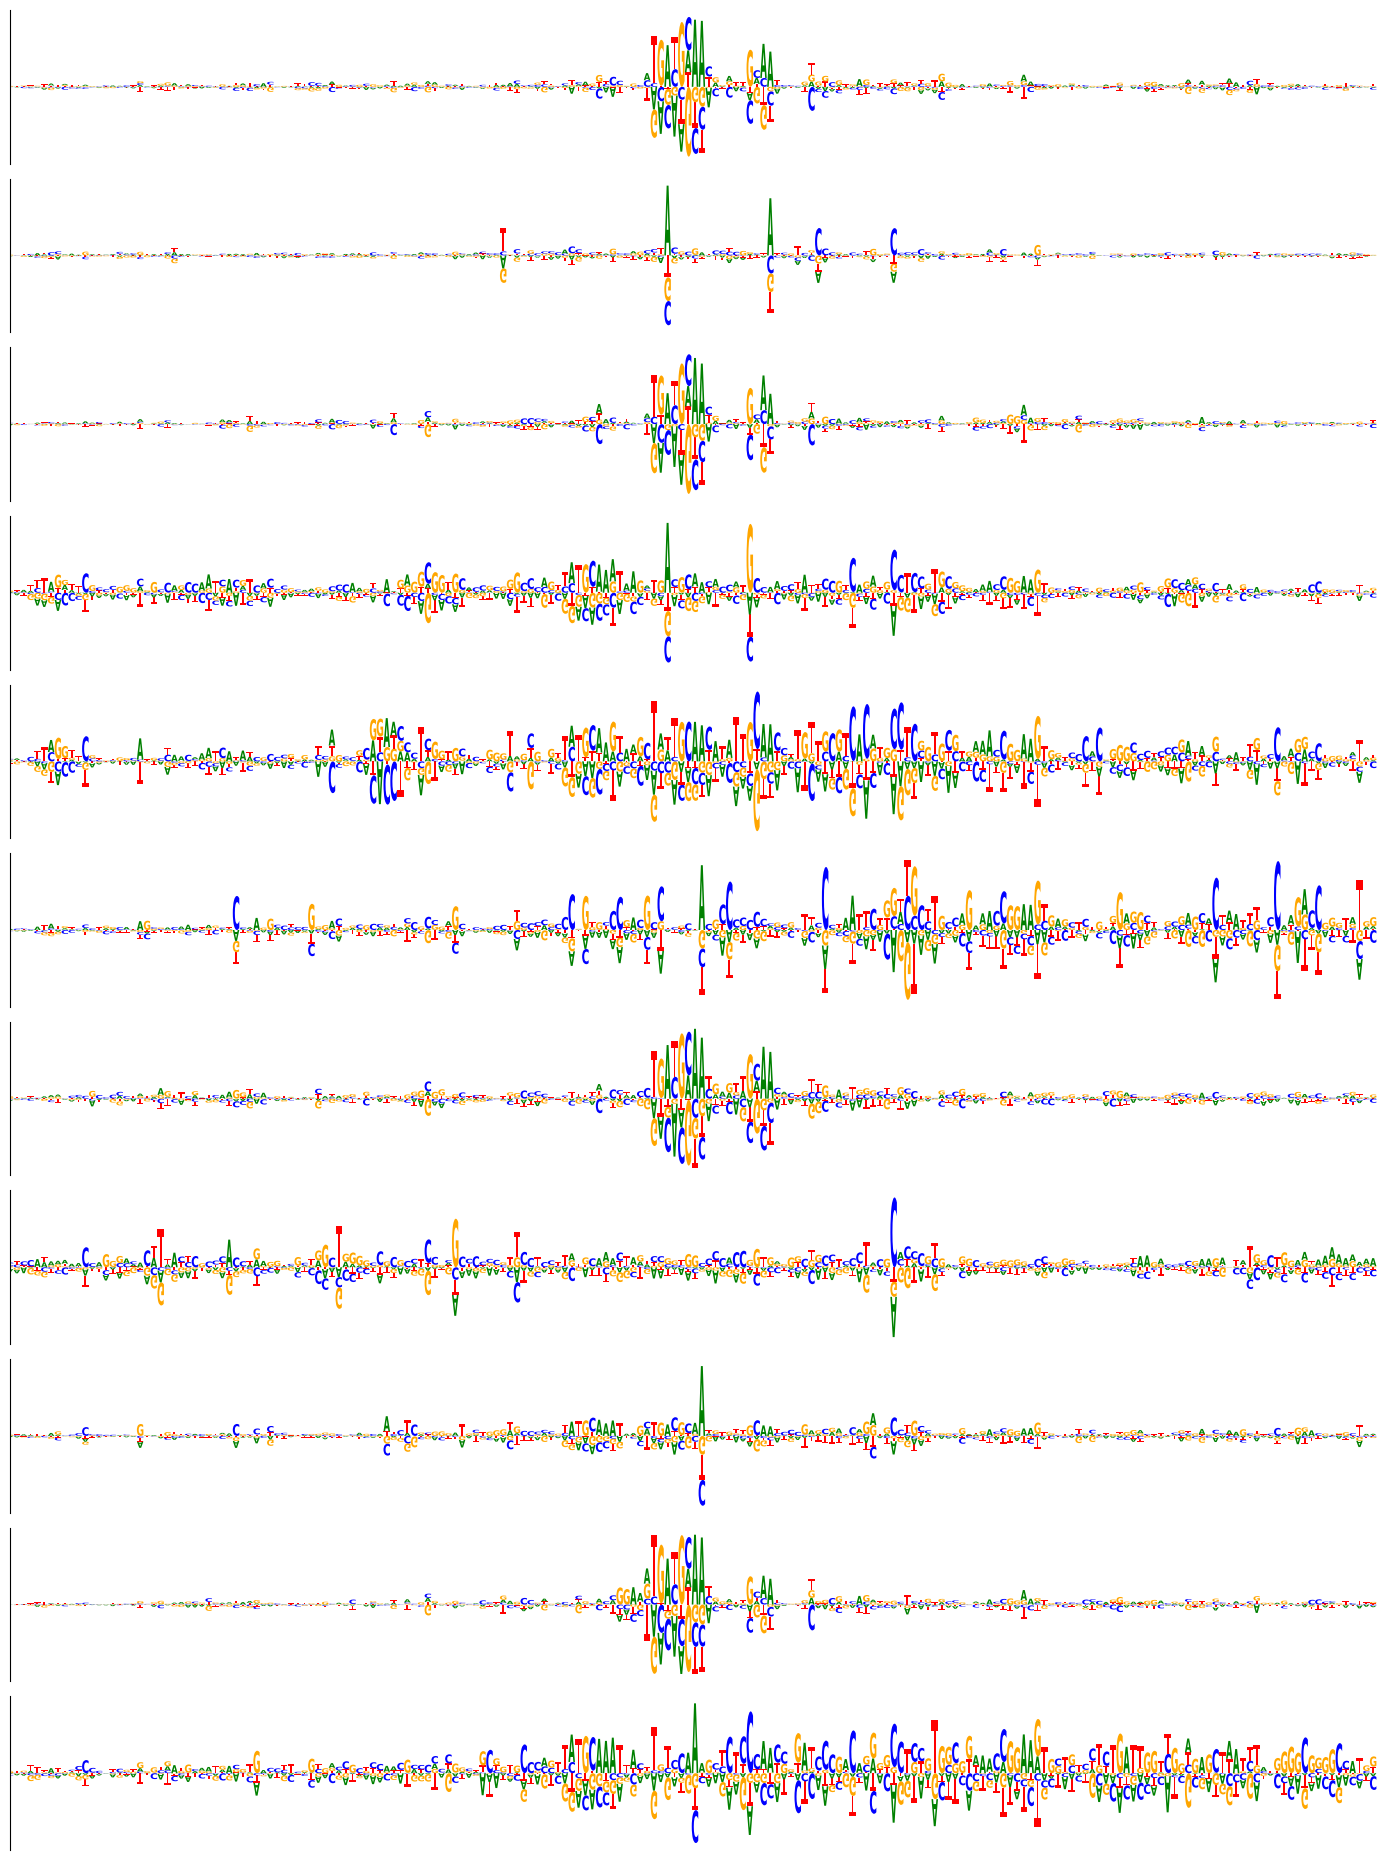

saved: /grid/koo/home/pmantill/projects/SEAM_validate/cluster_assess/results/peak84030_negctrl_300k_k300_random_members.png


In [38]:
# NEGATIVE CONTROL (bad example): the starred config's matched RANDOM control, its WT cluster.
# A random subset of the same library -> no shared consensus. This cell: WT reference + 10 random members.
import sys
sys.path.insert(0, "/grid/koo/home/pmantill/projects/EigenMaps/eigen-interactions")
from fast_logo import fast_logo

rand_run = next(r for r in runs if r["label"] == "rand-" + SEL_LABEL)      # negative control of starred config
rlabels  = rand_run["random_labels"]
members  = np.where(rlabels == int(rlabels[0]))[0]                          # random "WT cluster" (bin of row 0)
with h5py.File(rand_run["ism_h5"]) as f:
    maps = f["ism_centered"][:]                                            # (N, 200, 4)

wt_map = maps[0]                                                            # WT reference map (library row 0)
avg    = maps[members].mean(0)                                             # raw average of the random cluster
bg     = np.load(OUT / "recomputed_bg" / REF_SEQ / rand_run["label"] / "average_background_scaled.npy")
fg_avg = avg - bg                                                          # background-subtracted foreground

pick = np.random.default_rng(0).choice(members, size=min(10, len(members)), replace=False)

# WT reference + 10 random member maps
maps_to_plot = [wt_map] + [maps[int(i)] for i in pick]
fig, axes = plt.subplots(len(maps_to_plot), 1, figsize=(14, 1.7 * len(maps_to_plot)), sharex=False, squeeze=False)
for ax, m in zip(axes[:, 0], maps_to_plot):
    fast_logo(m, ax)                                                       # raw (L,4) map, full 4 channels
    ax.set_xlim(0, 200); ax.set_xticks([]); ax.set_yticks([])
    for sp in ("top", "right", "bottom"): ax.spines[sp].set_visible(False)
fig.tight_layout()
savename = f"{REF_SEQ}_negctrl_{SEL_LABEL}_random_members.png"
fig.savefig(OUT / savename, dpi=300, bbox_inches="tight")
plt.show()
print("saved:", OUT / savename)

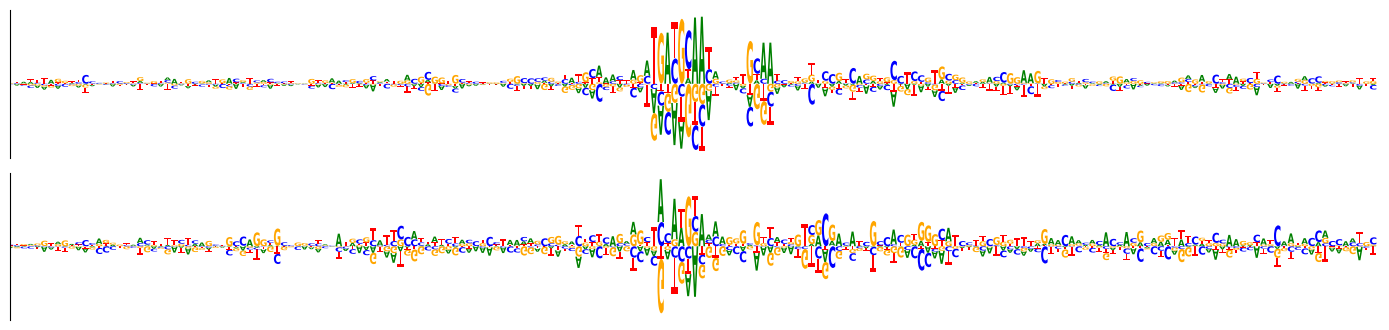

saved: /grid/koo/home/pmantill/projects/SEAM_validate/cluster_assess/results/peak84030_negctrl_300k_k300_avg_foreground.png


In [39]:
# Same negative control: cluster average (raw) and its background-subtracted foreground.
maps_to_plot = [avg, fg_avg]
fig, axes = plt.subplots(len(maps_to_plot), 1, figsize=(14, 1.7 * len(maps_to_plot)), sharex=False, squeeze=False)
for ax, m in zip(axes[:, 0], maps_to_plot):
    fast_logo(m, ax)                                                       # raw (L,4) map, full 4 channels
    ax.set_xlim(0, 200); ax.set_xticks([]); ax.set_yticks([])
    for sp in ("top", "right", "bottom"): ax.spines[sp].set_visible(False)
fig.tight_layout()
savename = f"{REF_SEQ}_negctrl_{SEL_LABEL}_avg_foreground.png"
fig.savefig(OUT / savename, dpi=300, bbox_inches="tight")
plt.show()
print("saved:", OUT / savename)